## ДЗ №1. Метрики и простейшие алгоритмы рекомендаций

## Общая информация
**Дата выдачи: 24 января 2026**

**Дедлайн: 8 февраля 2026 23:59 MSK**

In [293]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm.auto import tqdm
from typing import List, Optional
from metric_tests import run_tests

import matplotlib.dates as mdates
from scipy import sparse as sps

%matplotlib inline

np.random.seed(seed=42)


## О задании

В этой работе мы посмотрим на то, как работают самые простые модели для рекомендаций. Как правило, они не требуют построения специальных моделей, но даже так оказываются полезны в качестве бейзлайна. Попробуем сделать предсказания с помощью EASE. Это тоже довольно простой подход, но не стоит забывать, что сложные модели могут оказаться не лучшим выбором в условиях большого количества данных. Посчитаем метрики, построим графики и подумаем, насколько хорошо эти модели вообще решают поставленную задачу.

Мы будем работать с датасетом по рекомендации фильмов от Kion MTS, который был дан для соревнования. Сперва нужно его предобработать, эта часть повторяет то, что было на семинаре. 

Датасет необходимо скачать: https://ods.ai/competitions/competition-recsys-21/data

Оттуда нужны файлы `interactions.csv` и `items.csv`

Каждое задание весит **1 балл**, если выполнено полностью и без ошибок, **0 баллов** ставится при наличии хотя бы 1 ошибки. Максимальная оценка - **10 баллов**. Шаблоны функций и классов можно менять по своему усмотрению.

In [294]:
df = pd.read_csv('interactions.csv').iloc[:-1]
print('Первая дата:', df.last_watch_dt.min())
df.head()

Первая дата: 2021-03-13


,user_id,item_id,last_watch_dt,total_dur,watched_pct
0,176549,9506,2021-05-11,4250,72.0
1,699317,1659,2021-05-29,8317,100.0
2,656683,7107,2021-05-09,10,0.0
3,864613,7638,2021-07-05,14483,100.0
4,964868,9506,2021-04-30,6725,100.0


In [295]:
df['last_watch_dt'] = (pd.to_datetime(df['last_watch_dt']) - pd.to_datetime(df['last_watch_dt']).min())
df['last_watch_dt'] = df.last_watch_dt.apply(lambda x: int(str(x).split()[0]))
df.sample(5)

,user_id,item_id,last_watch_dt,total_dur,watched_pct
1300193,493726,7829,147,3198,49.0
4779785,380692,14215,14,4114,76.0
189880,152953,9163,53,211,4.0
4376570,167790,14703,139,4071,63.0
1372237,290886,7278,68,224,4.0


Сделаем разбиение по времени

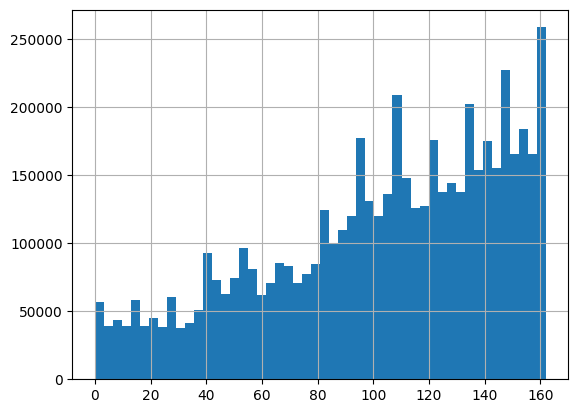

In [296]:
df.last_watch_dt.hist(bins=50);

In [297]:
train_df = df.loc[(df.last_watch_dt < 160-7)].copy()
test_df = df.loc[(df.last_watch_dt >= 160-7)].copy()

train_users = train_df.user_id.unique()
test_users = test_df.user_id.unique()

all_included = np.intersect1d(train_users, test_users)

print('число людей и там и там: ', all_included.shape[0])
print('число людей всего:', train_users.shape[0])

число людей и там и там:  134670
число людей всего: 880449


In [298]:
len(set(test_users) - set(train_users)) / len(test_users)

0.37768022181146027

И переведём всё к соединённому датасету:

In [299]:
n_users = 10000

all_included = np.random.choice(all_included, size=n_users, replace=False)

train_df = train_df.loc[train_df.user_id.isin(all_included)].copy()
test_df = test_df.loc[test_df.user_id.isin(all_included)].copy()

assert train_df.last_watch_dt.max() < test_df.last_watch_dt.min()
assert train_df.user_id.nunique() == n_users
assert test_df.user_id.nunique() == n_users

In [300]:
train_df.head()

,user_id,item_id,last_watch_dt,total_dur,watched_pct
66,750995,11699,2,12998,100.0
150,179618,9988,121,6811,100.0
312,84567,2720,151,181774,17.0
344,829804,12033,146,1577,25.0
367,848146,7977,131,1673,26.0


In [301]:
train_grouped = train_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                 x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
train_grouped.rename({0:'train_interactions'}, axis=1, inplace=True)

test_grouped = test_df.groupby('user_id').apply(
    lambda x: [(t1, t2) for t1, t2 in sorted(zip(x.item_id,
                                                         x.last_watch_dt), key=lambda x: x[1])]
).reset_index()
test_grouped.rename({0:'test_interactions'}, axis=1, inplace=True)

train_grouped.head()

,user_id,train_interactions
0,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10..."
1,164,"[(9728, 147), (10768, 148), (6431, 148), (1155..."
2,170,"[(13237, 152), (4331, 152)]"
3,175,"[(13865, 100), (9728, 109), (10440, 117), (128..."
4,272,"[(12869, 40), (11310, 112)]"


In [302]:
joined = train_grouped.merge(test_grouped)
joined.head()

,user_id,train_interactions,test_interactions
0,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234..."
1,164,"[(9728, 147), (10768, 148), (6431, 148), (1155...","[(6192, 153), (9563, 153), (6950, 153), (805, ..."
2,170,"[(13237, 152), (4331, 152)]","[(1453, 153), (741, 154), (15679, 154), (11083..."
3,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]"
4,272,"[(12869, 40), (11310, 112)]","[(5398, 156), (9728, 156), (6561, 156), (15214..."


In [303]:
np.random.seed(777)

class Random:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        items = set()
        for _, row in df.iterrows():
            for item, _ in row[col]:
                items.add(item)

        self.items = list(items)
        self.trained = True

    def predict(self, df, topn=10):
        assert self.trained
        return [np.random.choice(self.items, replace=False, size=topn)]*len(df)


random = Random()
random.fit(joined)

joined['random_recs'] = random.predict(joined, topn=3)
joined.head()

,user_id,train_interactions,test_interactions,random_recs
0,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234...","[10119, 7451, 11623]"
1,164,"[(9728, 147), (10768, 148), (6431, 148), (1155...","[(6192, 153), (9563, 153), (6950, 153), (805, ...","[10119, 7451, 11623]"
2,170,"[(13237, 152), (4331, 152)]","[(1453, 153), (741, 154), (15679, 154), (11083...","[10119, 7451, 11623]"
3,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]","[10119, 7451, 11623]"
4,272,"[(12869, 40), (11310, 112)]","[(5398, 156), (9728, 156), (6561, 156), (15214...","[10119, 7451, 11623]"


**Задание №1. Метрики и бейзлайны**

Добавьте реализацию метрик AP, RR, HR, их усреднённые версии по $U$ мы посчитаем ниже. За имплементацию с циклами балл будет снижаться, векторизуйте! ( ͡° ͜ʖ ͡°)

$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$
p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)
$$
$$
RR@k = \dfrac{1}{\text{rank}_i@k}
$$
$$
HR@k = [\exists \ y_i = 1 \ \text{among k preds}]
$$


*   $n_u$ - число айтемов, с которыми взаимодействовал юзер $u$
*   $y_i$ - релевантно ли $i$-ое предсказание, $y_i \in \{0,1\}$
* $\text{rank}_i@k$ - позиция первого релеваннтого айтема среди первых $k$ предсказаний
* HR@k - среди первых $k$ предсказаний есть хотя бы одно релевантное

Считайте, что если `topn` не задано, то в формуле нормализации MNAP вместо $\min(k, n_u)$ берётся  $n_u$, а списки предсказаний не обрезаются по `topn`. 

In [304]:
def ap_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    pred_arr = np.array(predictions)
    gt_arr = np.array(gt_items)

    n_u = len(gt_arr)
    if n_u == 0:
        return 0.0

    if topn is not None:
        pred_arr = pred_arr[:topn]

    relevance_mask = np.isin(pred_arr, gt_arr)
    if not np.any(relevance_mask):
        return 0.0

    hits_cumsum = np.cumsum(relevance_mask)
    ranks = np.arange(1, len(pred_arr) + 1)
    precisions = hits_cumsum / ranks
    sum_precisions = np.sum(precisions * relevance_mask)

    if topn is not None:
        normalization = min(topn, n_u)
    else:
        normalization = n_u

    return float(sum_precisions / normalization)


def rr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):
    pred_arr = np.array(predictions)
    gt_arr = np.array(gt_items)

    if topn is not None:
        pred_arr = pred_arr[:topn]

    relevance_mask = np.isin(pred_arr, gt_arr)
    relevance_indices = np.where(relevance_mask)[0]

    if len(relevance_indices) == 0:
        return 0.0

    first_relevant_index = relevance_indices[0]
    return 1.0 / (first_relevant_index + 1)

def hr_metric(
    gt_items: List[int],
    predictions: List[int],
    topn: Optional[int]=None
):

    pred_arr = np.array(predictions)
    gt_arr = np.array(gt_items)

    if topn is not None:
        pred_arr = pred_arr[:topn]

    is_hit = np.any(np.isin(pred_arr, gt_arr))
    return int(is_hit)


Для вашего удобства в файле `metric_tests.py` есть тесты, но хардкодить их, разумеется, не стоит. 

In [305]:
run_tests(ap_metric, rr_metric, hr_metric)

В следующей ячейке код, который считает и усредняет метрики по юзерам. Он взят с семинара, при желании можно его тоже модифицировать, например, векторизовать. 

In [306]:
def evaluate_recommender(df, model_preds, gt_col='test_interactions', topn=None):
    raw_gt = df[gt_col].values
    gt_list = [[x[0] for x in item] for item in raw_gt]
    gt_list = list(map(lambda x: x[0], raw_gt))
    pred_list = df[model_preds].values

    ap_scores = []
    rr_scores = []
    hr_scores = []

    for gt_items, predictions in zip(gt_list, pred_list):
        ap = ap_metric(gt_items, predictions, topn=topn)
        rr = rr_metric(gt_items, predictions, topn=topn)
        hr = hr_metric(gt_items, predictions, topn=topn)

        ap_scores.append(ap)
        rr_scores.append(rr)
        hr_scores.append(hr)

    return {
        'map': round(np.mean(ap_scores).item(), 4),
        'mrr': round(np.mean(rr_scores).item(), 4),
        'hr': round(np.mean(hr_scores).item(), 4)}

Если вы всё сделали правильно, рандомные предсказания должны дать хоть какое-то качество, но не очень большое.

In [307]:
evaluate_recommender(joined, model_preds='random_recs')

{'map': 0.0007, 'mrr': 0.0014, 'hr': 0.0014}

In [308]:
class TopPopular:

    def __init__(self):

        self.trained = False

    def fit(self, df, col='train_interactions'):

        counts = {}
        for _, row in df.iterrows():
            for item, _ in row[col]:
                if item in counts:
                    counts[item] += 1
                else:
                    counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommenations = [x[0] for x in counts]
        self.trained = True

    def predict(self, df, topn=10)  -> List[np.ndarray]:

        assert self.trained
        return [self.recommenations[:topn]]*len(df)


toppop = TopPopular()
toppop.fit(joined)

joined['toppopular_recs'] = toppop.predict(joined)
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs
0,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
1,164,"[(9728, 147), (10768, 148), (6431, 148), (1155...","[(6192, 153), (9563, 153), (6950, 153), (805, ...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
2,170,"[(13237, 152), (4331, 152)]","[(1453, 153), (741, 154), (15679, 154), (11083...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
3,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
4,272,"[(12869, 40), (11310, 112)]","[(5398, 156), (9728, 156), (6561, 156), (15214...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."


Самые популярные предсказания должны показать более высокое качество.

In [309]:
evaluate_recommender(joined, model_preds='toppopular_recs')

{'map': 0.0349, 'mrr': 0.0697, 'hr': 0.1629}

**Задание №2. Рекомендации в окне**

Здесь необходимо переделать метод рекомендации по популярности так, что популярность считается только за какое-то более свежее временное окно. Под окном подразумевается какой-то временной промежуток, например, ближайший месяц. Соответственно, всё что за его пределами, не учитывается.

In [390]:
class TopPopularWeighted(TopPopular):
    def __init__(self, window_size=30):
        super().__init__()
        self.window_size = window_size

    def fit(self, df, col='train_interactions'):
        all_dates = []
        for _, row in df.iterrows():
            for _, date in row[col]:
                all_dates.append(date)

        self.max_date = max(all_dates)
        self.min_date = min(all_dates)
        threshold = self.max_date - self.window_size

        counts = {}
        for _, row in df.iterrows():
            for item, date in row[col]:
                if date >= threshold:
                    if item in counts:
                        counts[item] += 1
                    else:
                        counts[item] = 1

        counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

        self.recommenations = [x[0] for x in counts]
        self.trained = True


Теперь постройте графики зависимости значений трёх метрик (AP@k, RR@k, HR@k) от размера окна. 

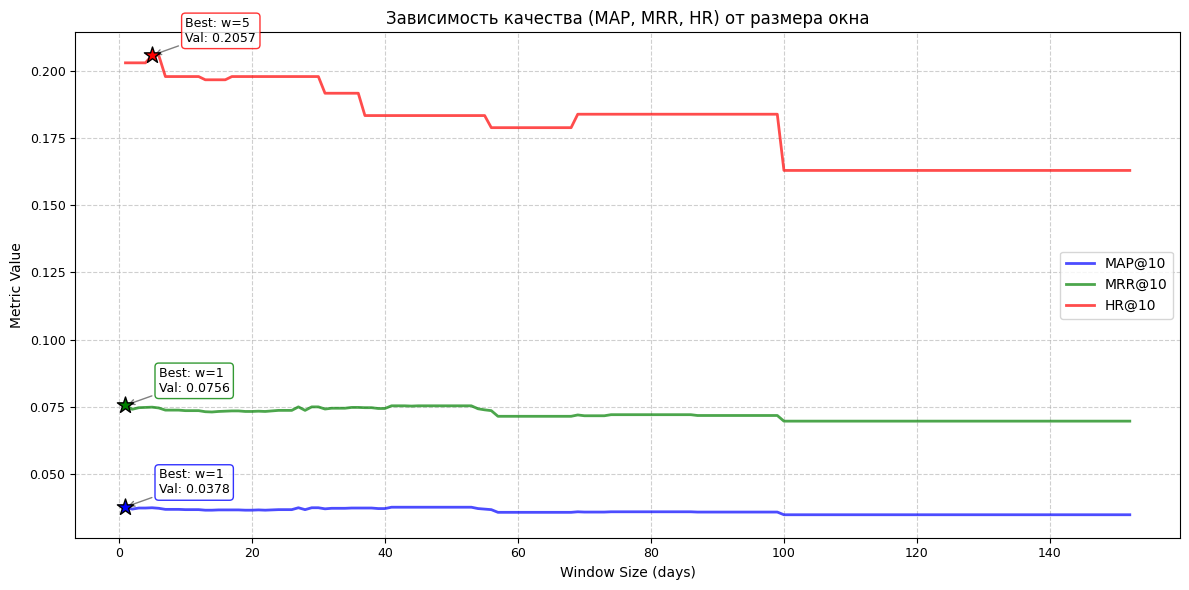

In [311]:
window_sizes = np.arange(1, 153)

map_scores = []
mrr_scores = []
hr_scores = []

for w in window_sizes:
    model = TopPopularWeighted(window_size=w)
    model.fit(joined, col='train_interactions')

    col_name = f'recs_window_temp'
    joined[col_name] = model.predict(joined, topn=10)

    metrics = evaluate_recommender(joined, model_preds=col_name)

    map_scores.append(metrics['map'])
    mrr_scores.append(metrics['mrr'])
    hr_scores.append(metrics['hr'])

del joined['recs_window_temp']



plt.figure(figsize=(12, 6))
metrics_data = [
    (map_scores, 'blue', 'MAP@10'),
    (mrr_scores, 'green', 'MRR@10'),
    (hr_scores, 'red', 'HR@10')
]

for scores, color, label in metrics_data:
    plt.plot(window_sizes, scores, label=label, color=color, linewidth=2, alpha=0.7)

    max_val = np.max(scores)
    best_idx = np.argmax(scores)
    best_w = window_sizes[best_idx]

    plt.scatter(best_w, max_val, color=color, s=150, marker='*', zorder=5, edgecolors='black')

    plt.annotate(f'Best: w={best_w}\nVal: {max_val:.4f}',
                 xy=(best_w, max_val),
                 xytext=(best_w + 5, max_val + 0.005),
                 fontsize=9,
                 arrowprops=dict(facecolor=color, arrowstyle='->', alpha=0.5),
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=color, alpha=0.8))


plt.title('Зависимость качества (MAP, MRR, HR) от размера окна', fontsize=12)
plt.xlabel('Window Size (days)', fontsize=10)
plt.ylabel('Metric Value', fontsize=10)

plt.tick_params(axis='both', which='major', labelsize=9)

plt.legend(fontsize=10, loc='center right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


Подумайте и ответьте, как размер окна влияет на качество рекомендаций. Какое значение наилучшее, есть ли у этого разумное объяснение?

**Ответ:**

На графике видна четкая **отрицательная корреляция**: увеличение размера окна ухудшает качество рекомендаций.
Наилучшим является окно **Window = 5**. В этой точке достигается максимум по Hit Rate (0.2057) при сохранении высоких показателей ранжирования (MAP/MRR).

**Почему это происходит?**
Здесь накладываются три фактора:

*   **Специфика домена (Фильмы):** Киноиндустрия движима новинками и хайпом. То, что было популярно 100 дней назад (старые блокбастеры), набрало огромную статистику, но сегодня уже не актуально или просмотрено большинством активных пользователей. Большое окно вытаскивает в топ «прошлое», зашумляя выдачу.
*   **Смена интересов:** Вкусы аудитории меняются быстро. Поведение пользователей за последнюю неделю (окно 5) гораздо точнее предсказывает их интересы на завтра, чем поведение полгода назад.
*   **Короткий тест (8 дней):** Тестовая выборка идет сразу за обучающей и длится всего неделю. Тренды в тесте статистически идентичны трендам последних дней трейна. Данные 3-месячной давности для такого короткого горизонта прогнозирования являются не сигналом, а шумом.

In [395]:
toppopw = TopPopularWeighted(window_size=5)
toppopw.fit(joined, col='train_interactions')
col_name = f'toppopularWindow'
joined[col_name] = toppopw.predict(joined, topn=100)

**Задание №3. Метрики и k.**

Постройте зависимость значений MAP@K, MRR@K, HR@K для метода рекомендации по популярности. Возьмите какие-нибудь k, например, от 1 до 100, переберите значения и покажите на линейном графике. 

In [ ]:
joined['toppopular_recs'] = toppop.predict(joined, topn=100)

k_values = np.arange(1, 101)

map_k = []
mrr_k = []
hr_k = []

for k in k_values:
    metrics = evaluate_recommender(
        joined,
        model_preds='toppopular_recs',
        gt_col='test_interactions',
        topn=k
    )

    map_k.append(metrics['map'])
    mrr_k.append(metrics['mrr'])
    hr_k.append(metrics['hr'])

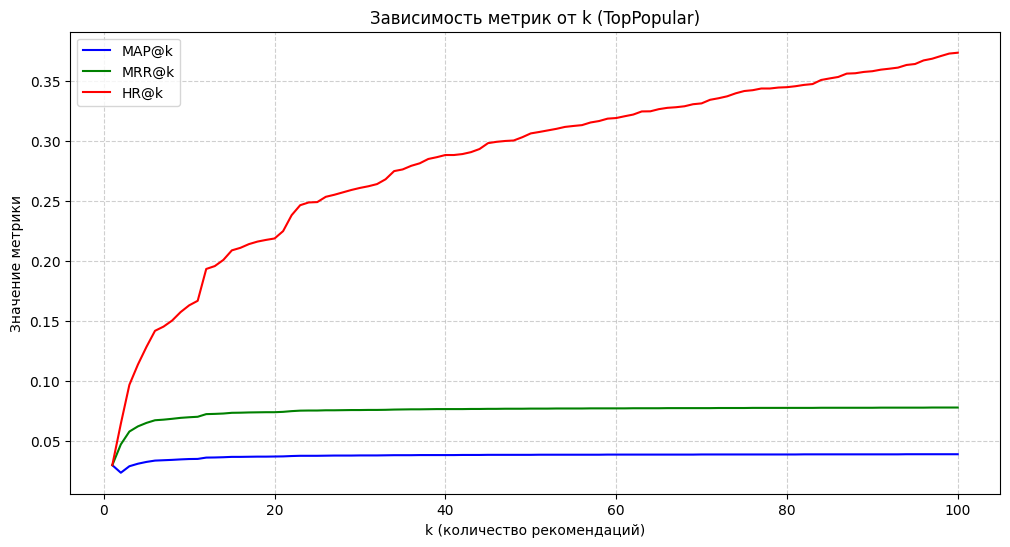

In [313]:
plt.figure(figsize=(12, 6))

plt.plot(k_values, map_k, label='MAP@k', color='blue')
plt.plot(k_values, mrr_k, label='MRR@k', color='green')
plt.plot(k_values, hr_k, label='HR@k', color='red')

plt.title('Зависимость метрик от k (TopPopular)')
plt.xlabel('k (количество рекомендаций)')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show();

Хорошенько подумайте и ответьте на вопросы ниже.

3.1 Какие из метрик являются монотонными функциями по top-K? Объясните, почему они являются монотонными? \
**Ответ:**

3.2 Объясните по каждой метрике, как можно интерпретировать ее график? То есть, что можно сказать про связь изменения метрики c возможными пользовательскими сценариями, например,скроллингом ленты новостей. \
**Ответ:**

3.3 Как вы думаете, почему графики выглядят именно так? Должны ли они возрастать/убывать, от чего это может зависеть? (Тут вам может помочь дополнительный анализ данных)\
**Ответ:**

**3.1 Монотонность**
*   **Монотонные (неубывающие): HR@k и MRR@k.**
    При расширении списка рекомендаций (увеличении $k$) мы просто добавляем новые товары. Мы не можем "потерять" уже найденные хиты, возможно лишь найти новые. Поэтому метрики либо растут, либо не меняются.
*   **Не монотонная: MAP@k.**
    В формуле есть деление на $k$. Если мы увеличиваем $k$, добавляя в конец списка нерелевантный товар, количество хитов (числитель) не меняется, а $k$ (знаменатель) растет — метрика падает.

**3.2 Интерпретация и сценарии**
*   **HR@k (Скроллинг ленты):** Показывает вероятность найти *хоть что-то* интересное. Рост графика говорит пользователю: «Листай дальше, шанс найти что-то интересное всё еще есть».
*   **MRR@k (Быстрый поиск / Виджеты):** Показывает, как быстро найдется *первый* результат. Выход на плато означает, что если пользователь не кликнул на первые 3-5 товаров, то дальше он, скорее всего, первый свой лайк уже не поставит (либо вклад этой находки в метрику ничтожен).
*   **MAP@k (Плейлисты):** Отражает «плотность» хороших рекомендаций. Низкий график означает, что лента «замусорена»: чтобы найти 5 хороших треков, пользователю придется пропустить 95 плохих.

**3.3 Причины формы графиков**
*   **Рост HR:** Обусловлен разнообразием вкусов. Топ-10 смотрят не все. Расширяя список до 100, TopPopular «цепляет» тех пользователей, чьи интересы лежат в более нишевых (менее популярных) фильмах.
*   **Плато MRR:** Математическая причина. Вклад хита на 50-й позиции равен $1/50 = 0.02$. Визуально на графике этот прирост почти не заметен, поэтому после $k=10$ линия кажется плоской.
*   **Низкий MAP:** Отсутствие персонализации. TopPopular не может выдать плотную пачку релевантных товаров конкретному юзеру, он постоянно «разбавляет» выдачу промахами, что тянет MAP вниз.

**Задание №4. Интерпретация рейтингов**

Возьмите названия фильмов/сериалов из `items.csv`, выделите 5 различных сценариев изменения популярности у фильмов, аргументируйте (например, графиком или статистикой) и проинтерпретируейте их (почему популярность для этого фильма меняется так). Обратите внимание, что надо найти именно разные паттерны изменения вероятностей. 

In [314]:
items = pd.read_csv('items.csv')[['item_id','title']].copy()
items.head()

,item_id,title
0,10711,Поговори с ней
1,2508,Голые перцы
2,10716,Тактическая сила
3,7868,45 лет
4,16268,Все решает мгновение


Пример:

1917


<Axes: >

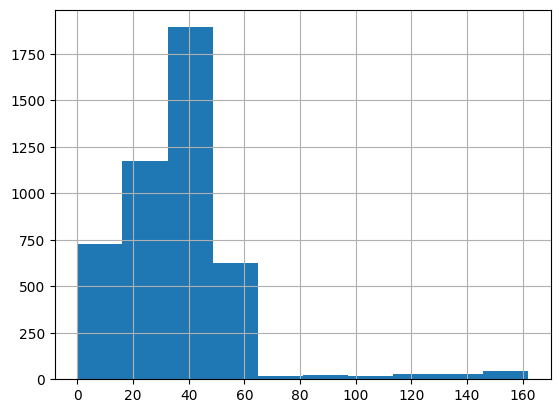

In [315]:
popular_items = df.item_id.value_counts()[:300].index.tolist()
sampled_id = np.random.choice(popular_items)

# это для примера, хотя выцеплять случаи по одному может быть не лучшей идеей
sampled_id = 3402

interactions = df.loc[df.item_id==sampled_id].copy()
name = items.loc[items.item_id==sampled_id].title.values[0]
print(name)
interactions.last_watch_dt.hist()

Фильм 1917 какое-то время набирал популярность, потом видим резкое падение (кстати, с какой даты?). Возможно, это связано с ограничением доступности этого фильма для части пользователей, периодом проката фильма / рекламной кампании или другой причиной. 

Добавьте 5 своих примеров ниже. Опишите, как вы их искали. 

>Как я искал примеры 

1.  **Блокбастер (Угасание):** Использовал фильтр `early_mask` (максимум популярности в первые 4 недели) и сортировка по `decay_score` (отношение активности в начале к концу). Дополнительно проверял, что фильм не исчез полностью (`alive_at_end`), чтобы отличить от ухода с платформы.
2.  **Стабильный (Evergreen):** Вычислял коэффициент вариации (CV = std/mean). Фильм с минимальным CV имеет самый ровный график без резких скачков.
3.  **Новинка каталога (Рост):** Считал разницу средних просмотров между концом и началом периода (`growth_score`). Максимальная разница означает, что фильм стартовал с нуля и вышел на плато.
4.  **Внезапный хайп:** Фильтровались фильмы, у которых максимум (`max=1.0`) находился строго в середине временного ряда (`mid_peak_mask`). Чтобы отличить от новинок, добавил условие `low_end`: активность в конце периода должна быть существенно ниже пика.
5.  **Уход с платформы:** Искал фильмы с высокой активностью в начале (`drop_score`) и строго нулевыми просмотрами в последнюю неделю (`true_drop_mask`).

In [316]:
# Стартовая дата
start_date = pd.Timestamp('2021-03-13')

# Группировка по неделям
df['week'] = df['last_watch_dt'] // 7
pivot = df.pivot_table(index='item_id', columns='week', values='user_id', aggfunc='count', fill_value=0)

total_counts = pivot.sum(axis=1)
active_items = pivot[total_counts > 100].index
matrix = pivot.loc[active_items]
norm_matrix = matrix.div(matrix.max(axis=1), axis=0) # Нормализация 0-1
n_weeks = norm_matrix.shape[1]

found_scenarios = {}

# --- СЦЕНАРИЙ 1: Блокбастер (Угасание) ---
early_mask = norm_matrix.iloc[:, :4].max(axis=1) == 1.0
alive_at_end = norm_matrix.iloc[:, -5:].mean(axis=1) > 0.01
decay_score = norm_matrix.iloc[:, :5].mean(axis=1) / (norm_matrix.iloc[:, -5:].mean(axis=1) + 0.001)
found_scenarios['Блокбастер (Угасание)'] = decay_score[early_mask & alive_at_end].idxmax()

# --- СЦЕНАРИЙ 2: Стабильный (Evergreen) ---
cv = matrix.std(axis=1) / (matrix.mean(axis=1) + 0.01)
found_scenarios['Стабильный (Evergreen)'] = cv.idxmin()

# --- СЦЕНАРИЙ 3: Новинка каталога (Рост) ---

growth_score = norm_matrix.iloc[:, -5:].mean(axis=1) - norm_matrix.iloc[:, :5].mean(axis=1)
found_scenarios['Новинка каталога (Рост)'] = growth_score.idxmax()

# --- СЦЕНАРИЙ 4: Внезапный Хайп ---
mid_start, mid_end = int(n_weeks*0.3), int(n_weeks*0.7)
mid_peak_mask = norm_matrix.iloc[:, mid_start:mid_end].max(axis=1) == 1.0
low_start = norm_matrix.iloc[:, :mid_start].mean(axis=1) < 0.2
low_end = norm_matrix.iloc[:, mid_end:].mean(axis=1) < 0.4 # Падает после хайпа
spike_score = norm_matrix.iloc[:, mid_start:mid_end].mean(axis=1) / \
              (norm_matrix.iloc[:, :mid_start].mean(axis=1) + norm_matrix.iloc[:, mid_end:].mean(axis=1) + 0.01)
found_scenarios['Внезапный хайп'] = spike_score[mid_peak_mask & low_start & low_end].idxmax()

# --- СЦЕНАРИЙ 5: Уход / Потеря прав ---
drop_score = norm_matrix.iloc[:, :5].mean(axis=1) - norm_matrix.iloc[:, -3:].mean(axis=1)
true_drop_mask = norm_matrix.iloc[:, -1] == 0
found_scenarios['Уход / Потеря прав'] = drop_score[true_drop_mask].idxmax()

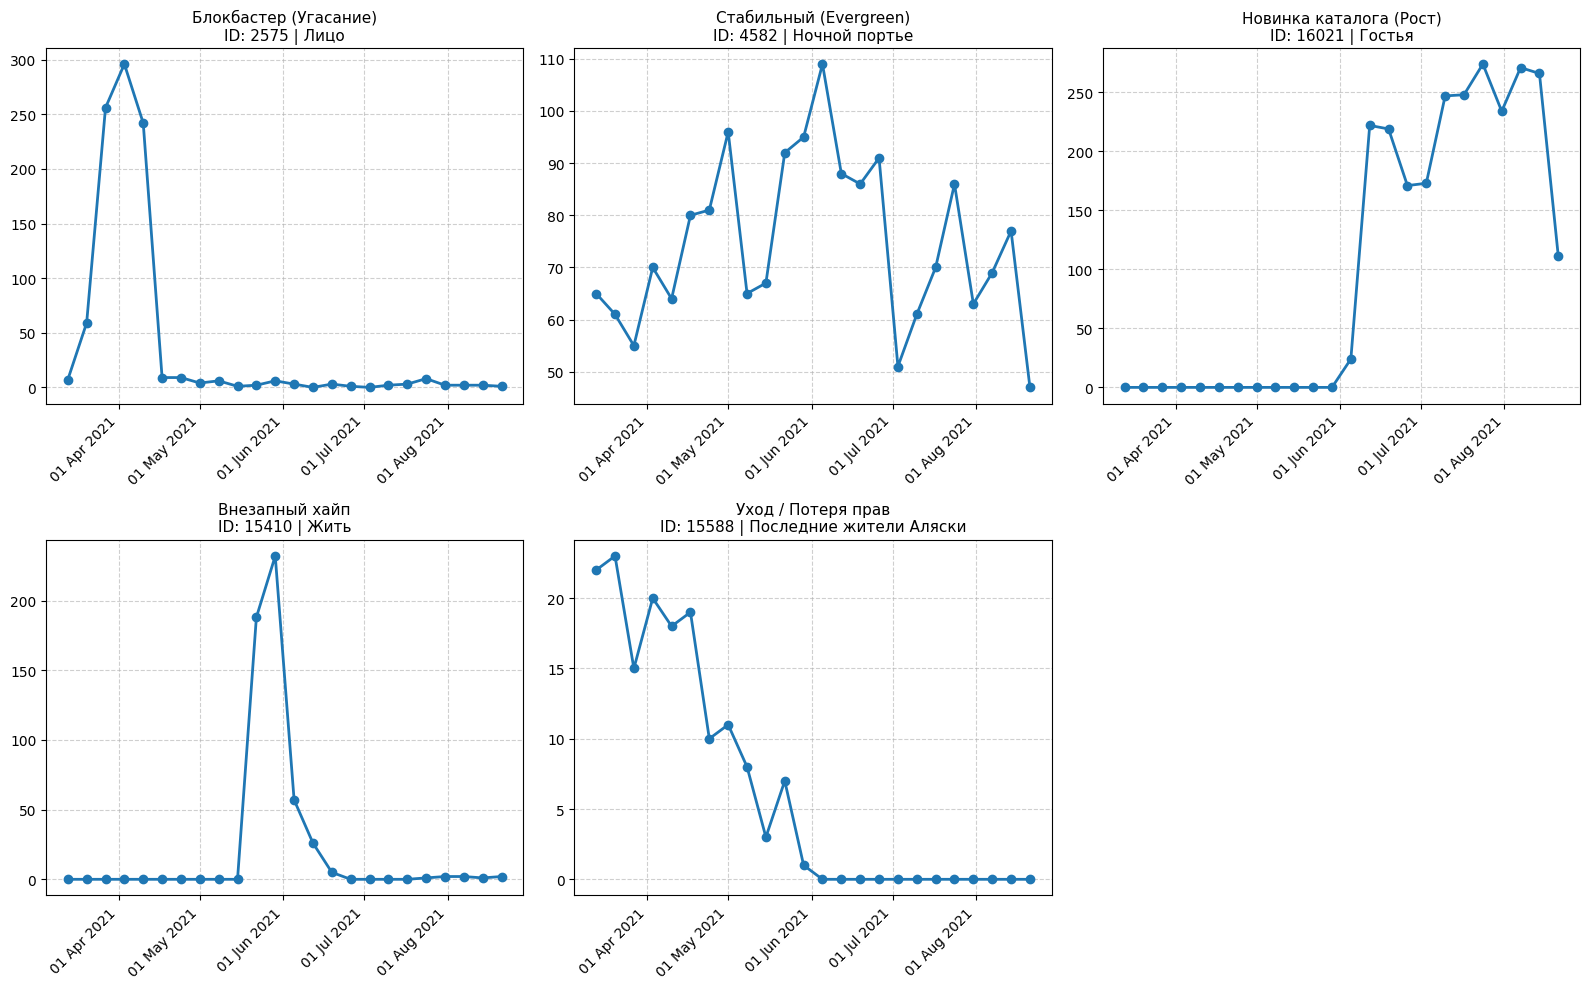

In [317]:
plt.figure(figsize=(16, 10))
date_fmt = mdates.DateFormatter('%d %b %Y')

for i, (desc, item_id) in enumerate(found_scenarios.items()):
    ax = plt.subplot(2, 3, i+1)

    y_vals = matrix.loc[item_id]
    # Конвертируем индексы недель в даты
    x_dates = [start_date + pd.Timedelta(weeks=w) for w in matrix.columns]
    title = items.loc[items.item_id == item_id, 'title'].values[0]
    ax.plot(x_dates, y_vals, marker='o', linewidth=2)
    ax.set_title(f"{desc}\nID: {item_id} | {title}", fontsize=11)

    # Настройка оси времени
    ax.xaxis.set_major_formatter(date_fmt)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

    АНАЛИЗ 

>1. Блокбастер (Угасание)
**Фильм:** *Лицо (ID: 2575)*
*   **Паттерн:** Мы видим резкий взлет до пика (~300 просмотров) в первые 3-4 недели, после чего происходит мгновенное падение почти до нуля.
*   **Интерпретация:** Это классический эффект **громкой премьеры**. Скорее всего, фильм активно рекламировался на главной странице или в баннерах платформы. Аудитория "съела" новинку очень быстро (эффект страха пропустить / FOMO), но у фильма нет потенциала для пересмотра, поэтому, как только волна маркетинга спала, интерес исчез.

> 2. Стабильный
**Фильм:** *Ночной портье (ID: 4582)*
*   **Паттерн:** График не имеет выраженного тренда, просмотры колеблются в диапазоне 50–110 на протяжении всего времени. Нет падений в ноль.
*   **Интерпретация:** Это **вечнопопулярный контент**. Скорее всего, культовая классика или нишевое кино, которое находит своего зрителя органически (через поиск или рекомендации) без активной рекламы. 

> 3. Новинка каталога (Рост)
**Фильм:** *Гостья (ID: 16021)*
*   **Паттерн:** Абсолютный ноль просмотров до 12-й недели. Затем резкий скачок вверх и удержание высокого уровня просмотров.
*   **Интерпретация:** Проблема **холодного старта / Пополнение каталога**. Физически этого фильма не было на платформе до 12-й недели (либо на него не было лицензии). Как только фильм загрузили и открыли к нему доступ, он попал в раздел "Новинки", что спровоцировало стабильный интерес пользователей.

>4. Внезапный хайп
**Фильм:** *Жить (ID: 15410)*
*   **Паттерн:** Полный штиль (0 просмотров) в начале и конце графика, но есть огромный одиночный "выстрел" (парабола) между 10 и 13 неделями.
*   **Интерпретация:** Влияние **внешнего инфоповода (External Trigger)**. Сам по себе фильм, не новый (2012 год). Всплеск скорее всего обусловлен событием в реальном мире: фильм показали по ТВ, и тд

> 5. Уход / Потеря прав
**Фильм:** *Последние жители Аляски (ID: 15588)*
*   **Паттерн:** Умеренный интерес в начале графика, который постепенно снижается, а на 11-й неделе обрывается в строгий ноль и больше не восстанавливается.
*   **Интерпретация:** **Истечение лицензии**. Онлайн-кинотеатр потерял права на показ этого контента, и он был удален из библиотеки. Нулевые значения подтверждают, что фильм стал технически недоступен для пользователей.

**Задание №5. User-item encoding**

Теперь, создайте матрицу интеракций user-item по примеру из семинара. Вам нужно в итоге получить разреженную матрицу (sparse matrix), в которой в качестве строк будут пользователи, в качестве колонок - айтемы. Не забудьте перекодировать пользователей и айтемы через энкодер. В отличие от семинара, оставьте в матрице только юзеров и айтемы, которые встречались в матрице > 4 раз.

Важно: когда вы отфильтруете юзеров на встречаемость > 4 раз, вы удалите какие-то айтемы, которые теперь станут встречаться меньше 5 раз. Поэтому у вас перестанет выполняться второе условие на минимальное число интеракций с айтемом. Тогда вам надо опять отфильтровать айтемы на встречаемость, но это снова может нарушить условие для юзеров. В таком случае, вам надо написать итеративный алгоритм до сходимости, пока требования не будут выполняться в обеих колонках. 

In [318]:
def filter_column(df, col, min_freq):
    counts = df[col].value_counts()
    valid_ids = counts[counts >= min_freq].index
    return df[df[col].isin(valid_ids)].copy()

def filter_dataframe(df, cols, min_freq=5):
    df_copy = df.copy()
    step = 0

    while True:
        start_shape = df_copy.shape
        for col in cols:
            df_copy = filter_column(df_copy, col, min_freq)

        end_shape = df_copy.shape
        if start_shape == end_shape:
            break

        step += 1
    return df_copy

In [334]:
filtered_train = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=5)
print(f"Original shape: {train_df.shape}")
print(f"Filtered shape: {filtered_train.shape}")

Original shape: (121903, 5)
Filtered shape: (105386, 5)


In [335]:
def df_encode(df):
    user2id = {k.item(): v for v, k in enumerate(df['user_id'].unique())}
    item2id = {k.item(): v for v, k in enumerate(df['item_id'].unique())}

    df_encoded = df.copy()
    df_encoded['user_id'] = df_encoded['user_id'].map(user2id)
    df_encoded['item_id'] = df_encoded['item_id'].map(item2id)

    return df_encoded, user2id, item2id


filtered_train, user2id, item2id = df_encode(filtered_train)

print(f"Unique users: {len(user2id)}, Unique items: {len(item2id)}")
filtered_train.sample(5)

Unique users: 5758, Unique items: 3114


,user_id,item_id,last_watch_dt,total_dur,watched_pct
1891435,4953,185,126,1419901,88.0
3681283,1680,1212,114,1058,12.0
4686034,3424,862,14,21149,24.0
1960296,5313,1919,143,1048,15.0
314672,859,629,0,4747,93.0


In [336]:
matrix = sps.coo_matrix(
    (np.ones(filtered_train.shape[0]), (filtered_train['user_id'], filtered_train['item_id'])),
    shape=(len(user2id), len(item2id)),
)
matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 105386 stored elements and shape (5758, 3114)>

**Задание №6. Интеракции и частота**

Постройте график зависимости количества айтемов и юзеров от значений (порогов) фильтров на встречаемость в матрице интеракций. То есть, нужно выполнить задание №5 для нескольких значений `min_freq` и построить график зависимости числа оставшихся айтемов и юзеров от этого параметра. 

In [337]:
num_users, num_items = [], []
thresholds = range(1, 26)
for threshold in thresholds:
    filtered_train_temp = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=threshold)
    _, user2id_temp, item2id_temp = df_encode(filtered_train_temp)
    num_users.append(len(user2id_temp))
    num_items.append(len(item2id_temp))


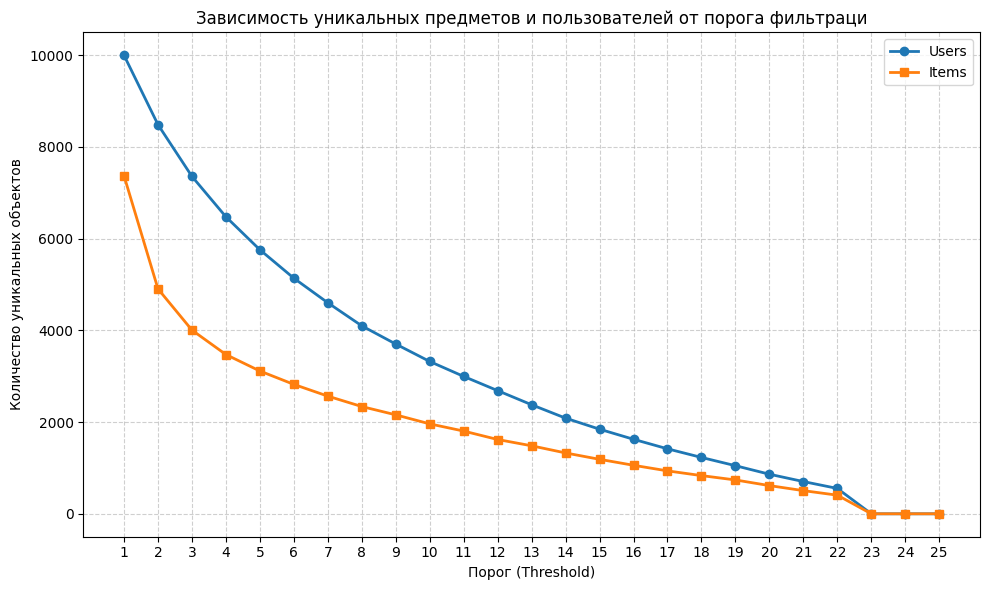

In [338]:
plt.figure(figsize=(10, 6))

plt.plot(thresholds, num_users, 'o-', label='Users', linewidth=2)
plt.plot(thresholds, num_items, 's-', label='Items', linewidth=2)

plt.title('Зависимость уникальных предметов и пользователей от порога фильтраци')
plt.xlabel('Порог (Threshold)')
plt.ylabel('Количество уникальных объектов')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(thresholds)

plt.tight_layout()
plt.show()



1.  Резкое падение в начале (с порога 1 до 5) указывает на то, что **большинство** пользователей и предметов имеют очень мало взаимодействий (1-3). Увеличение порога всего до 5 отсеивает почти 40-50% данных.

2.  Поскольку алгоритм фильтрации работает итеративно (удаление юзеров уменьшает счетчики айтемов и наоборот), график падает быстрее, чем если бы мы фильтровали колонки независимо. Это эффект "снежного кома".

3.  На пороге **23** график падает в ноль. Это означает, что в данном датасете физически не существует плотного подграфа , где каждый пользователь посмотрел бы минимум 23 фильма, а каждый фильм посмотрели бы минимум 23 пользователя. При таком строгом фильтре матрица становится пустой.



**Задание №7. EASE**

Реализуйте EASE, постройте рекомендации для юзеров. Сравните все имплементированные ранее метрики качества с `TopPopular` для некоторого набора k. 

Реализацию можно взять из семинара. Можно реализовать по статье https://arxiv.org/pdf/1905.03375.pdf. Можно взять и адаптировать из RecBole https://github.com/RUCAIBox/RecBole.

In [ ]:
%%time

# Обучаем конечную модель
# Мы взяли реализацию из RecBole
def fit_ease(X, reg_weight=100):

    # gram matrix
    G = X.T @ X

    # add reg to diagonal
    G += reg_weight * sps.identity(G.shape[0])

    # convert to dense because inverse will be dense
    G = G.todense()

    # invert. this takes most of the time
    P = np.linalg.inv(G)
    B = P / (-np.diag(P))
    # zero out diag
    np.fill_diagonal(B, 0.)

    return B

w = fit_ease(matrix)


CPU times: user 540 ms, sys: 3.34 ms, total: 543 ms
Wall time: 543 ms


Далее, вам надо реализовать функцию получения предсказаний. У вас есть обученная матрица весов, которую можно использовать для получения предсказаний. Для этого нужно построить вектор интеракций пользователя и умножить его на матрицу весов.

In [369]:
def get_preds(x, item2id, w, topk = 100):
    item_ids = [item2id[item] for item, _ in x if item in item2id]

    vector = np.zeros(len(item2id), dtype=np.float32)
    vector[item_ids] = 1.0
    vector = sps.csr_matrix(vector)

    preds = np.asarray(vector.dot(w)).ravel()
    preds[item_ids] = -np.inf

    pred_ids = np.argsort(-preds)[:topk]
    id2item = {v:k for k, v in item2id.items()}
    pred_items = [id2item[item_id] for item_id in pred_ids]
    return pred_items


joined['ease_preds'] = joined.train_interactions.apply(lambda x: get_preds(x, item2id, w))
joined.head()

,user_id,train_interactions,test_interactions,random_recs,toppopular_recs,ease_preds,toppopularWindow
0,30,"[(4740, 88), (676, 91), (12418, 98), (9728, 10...","[(15363, 153), (11253, 153), (1107, 154), (234...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[13865, 2657, 3734, 10440, 15297, 12356, 6162,...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
1,164,"[(9728, 147), (10768, 148), (6431, 148), (1155...","[(6192, 153), (9563, 153), (6950, 153), (805, ...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[10440, 15297, 13865, 3734, 8636, 3509, 6809, ...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
2,170,"[(13237, 152), (4331, 152)]","[(1453, 153), (741, 154), (15679, 154), (11083...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[1978, 11919, 7592, 12455, 874, 3510, 3959, 14...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
3,175,"[(13865, 100), (9728, 109), (10440, 117), (128...","[(15297, 153)]","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[15297, 3734, 9996, 12995, 2657, 8636, 142, 12...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."
4,272,"[(12869, 40), (11310, 112)]","[(5398, 156), (9728, 156), (6561, 156), (15214...","[10119, 7451, 11623]","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ...","[13018, 12275, 6809, 9091, 1287, 12995, 13290,...","[10440, 15297, 9728, 13865, 3734, 4151, 4880, ..."


In [403]:
history = {
    'k': np.arange(1, 101),
    'ease': {'map': [], 'mrr': [], 'hr': []},
    'pop':  {'map': [], 'mrr': [], 'hr': []},
    'popw':  {'map': [], 'mrr': [], 'hr': []}
}

for k in history['k']:

    m_pop = evaluate_recommender(
        joined, model_preds='toppopular_recs', gt_col='test_interactions', topn=k
    )

    m_pop_w = evaluate_recommender(
        joined, model_preds='toppopularWindow', gt_col='test_interactions', topn=k
    )

    m_ease = evaluate_recommender(
        joined, model_preds='ease_preds', gt_col='test_interactions', topn=k
    )

    history['pop']['map'].append(m_pop['map'])
    history['pop']['mrr'].append(m_pop['mrr'])
    history['pop']['hr'].append(m_pop['hr'])

    history['popw']['map'].append(m_pop_w['map'])
    history['popw']['mrr'].append(m_pop_w['mrr'])
    history['popw']['hr'].append(m_pop_w['hr'])

    history['ease']['map'].append(m_ease['map'])
    history['ease']['mrr'].append(m_ease['mrr'])
    history['ease']['hr'].append(m_ease['hr'])

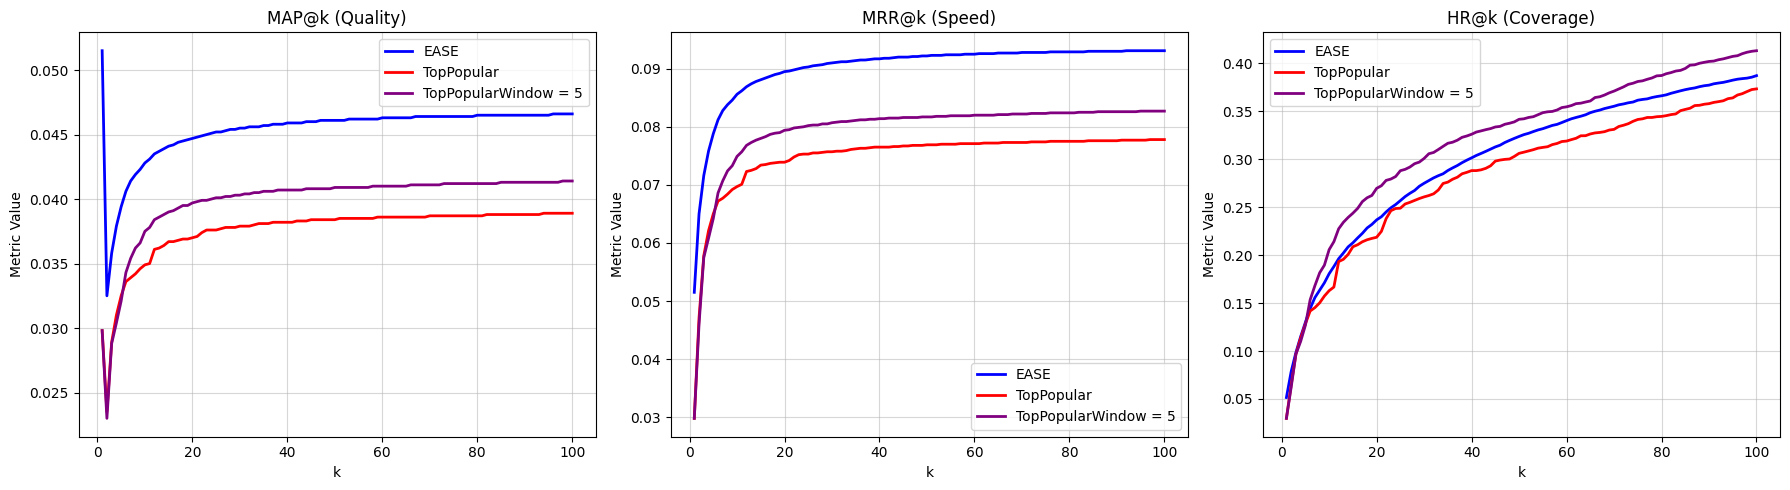

In [404]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_list = ['map', 'mrr', 'hr']
titles = ['MAP@k (Quality)', 'MRR@k (Speed)', 'HR@k (Coverage)']

for i, metric in enumerate(metrics_list):
    ax = axes[i]

    ax.plot(history['k'], history['ease'][metric], label='EASE', color='blue', linewidth=2)
    ax.plot(history['k'], history['pop'][metric], label='TopPopular', color='red', linewidth=2)
    ax.plot(history['k'], history['popw'][metric], label='TopPopularWindow = 5', color='purple', linewidth=2)


    ax.set_title(titles[i])
    ax.set_xlabel('k')
    ax.set_ylabel('Metric Value')
    ax.legend()
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Сделайте выводы — какой алгоритм работает лучше?

**Ответ:**


1.  **Безусловный лидер — EASE (Синяя линия).**
    Она показывает лучшее качество ранжирования (**MAP** и **MRR**) на всем диапазоне. Персонализация работает: модель понимает вкусы юзера и ставит нужные фильмы на первые места, значительно опережая методы популярности.

2.  **Эффект новизны.**
    **TopPopularWindow (Фиолетовая)** стабильно обходит обычный TopPopular. Это доказывает, что рекомендовать "свежие хиты" (тренды недели) намного эффективнее, чем "старые хиты" за все время.

3.  **Аномалия Hit Rate.**
    На длинных списках ($k > 20$) **Window-модель** обгоняет EASE по охвату (**HR**).
    *Причина:* Если показывать пользователю 100 фильмов, статистически проще угадать его интерес, предложив "хайповые новинки", которые смотрят все. Однако EASE гораздо точнее в **Топ-10**, что важнее для бизнеса.

**Задание №8. Тюнинг**

Переберите различные значения гиперпараметра коэффициента регуляризации у EASE и постройте графики, как в задании №6. Постарайтесь "затюнить" EASE как можно лучше. Возьмите разумное число гиперпараметров - хотя бы штук 20 по логарифмической сетке, либо используйте более хитрые алгоритмы оптимизации. 

In [405]:
lambdas = np.geomspace(1, 10000, num=20)

tuning_results = {
    'lambda': [],
    'map': [],
    'mrr': [],
    'hr': []
}


for reg in lambdas:
    w_curr = fit_ease(matrix, reg_weight=reg)
    col_name = 'temp_ease_preds'
    joined[col_name] = joined.train_interactions.apply(
        lambda x: get_preds(x, item2id, w_curr, topk=10)
    )

    metrics = evaluate_recommender(
        joined,
        model_preds=col_name,
        gt_col='test_interactions',
        topn=10
    )


    tuning_results['lambda'].append(reg)
    tuning_results['map'].append(metrics['map'])
    tuning_results['mrr'].append(metrics['mrr'])
    tuning_results['hr'].append(metrics['hr'])

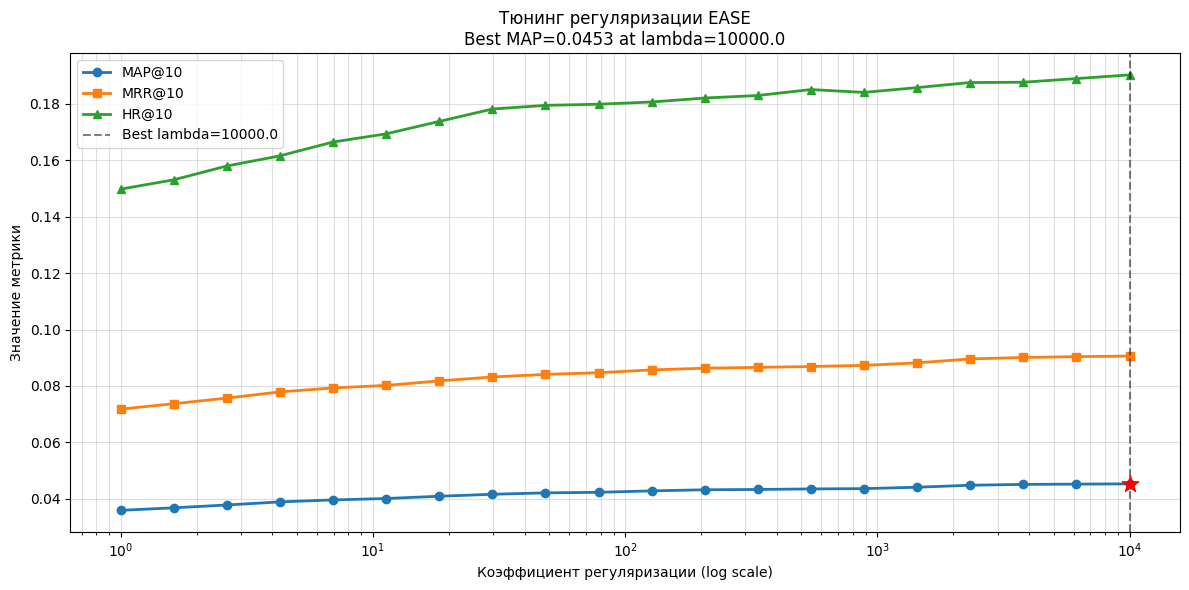

Лучшее значение lambda: 10000.0


In [411]:
best_idx = np.argmax(tuning_results['map'])
best_lambda = tuning_results['lambda'][best_idx]
best_map = tuning_results['map'][best_idx]

plt.figure(figsize=(12, 6))

plt.semilogx(tuning_results['lambda'], tuning_results['map'], 'o-', label='MAP@10', linewidth=2)
plt.semilogx(tuning_results['lambda'], tuning_results['mrr'], 's-', label='MRR@10', linewidth=2)
plt.semilogx(tuning_results['lambda'], tuning_results['hr'], '^-', label='HR@10', linewidth=2)

plt.axvline(x=best_lambda, color='black', linestyle='--', alpha=0.5, label=f'Best lambda={best_lambda:.1f}')
plt.scatter(best_lambda, best_map, color='red', s=150, zorder=5, marker='*')

plt.title(f'Тюнинг регуляризации EASE\nBest MAP={best_map:.4f} at lambda={best_lambda:.1f}')
plt.xlabel('Коэффициент регуляризации (log scale)')
plt.ylabel('Значение метрики')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Лучшее значение lambda: {best_lambda}")



**8.1 Какое значение гиперпараметра является наилучшим?**

**Ответ:**
Наилучшим из проверенных значений является **$\lambda = 10000.0$**.
На графике видно, что метрика MAP (как и остальные) достигает своего максимума в крайней правой точке исследуемого диапазона. Поскольку график монотонно возрастает и мы не увидели явного пика с последующим падением, можно предположить, что истинный оптимум находится либо в точке 10000, либо даже правее.

**8.2 Что еще интересного вы можете сказать по графикам? Может быть, что-то связанное с распределением параметров, влиянием на отдельные метрики, скоростью тюнинга?**

**Ответ:**

1.  **Отсутствие переобучения (в рамках сетки):** Обычно графики регуляризации имеют форму "холма" (недообучение -> оптимум -> переобучение). Здесь мы видим, что модель требует **очень сильной регуляризации**. Это может говорить о высокой разреженности матрицы или шумности данных: модели выгодно сильно штрафовать веса (прижимать их к нулю), чтобы не выучивать случайные совпадения.
2.  **Синхронность метрик:** Все три метрики (MAP, MRR, HR) ведут себя абсолютно коррелированно. Изменение $\lambda$ одинаково влияет и на точность ранжирования (MRR/MAP), и на охват (HR). Нет ситуации trade-off, когда одна метрика растет за счет падения другой.
3.  **Затухающий рост (Diminishing returns):** Основной прирост качества происходит в диапазоне $\lambda$ от 1 до 100. Далее график выходит на плато. Разница между $\lambda=1000$ и $\lambda=10000$ минимальна, хотя формально 10000 лучше. В продакшене можно было бы остановиться на 1000, если бы это давало какой-то выигрыш (но в EASE $\lambda$ не влияет на скорость инференса).


**Задание №9. EASE и topk**

В лекции №2 говорилось, что качество у EASE растет с ослаблением фильтра на число айтемов. В этом задании постройте кривые метрик качества MAP/MRR/HR в зависимости от topk (например, от 1 до 100 с некоторым шагом), где кривая параметризована минимальным требуемым значением встречаемости user/item (из задания №6). Опишите свои выводы.

Важно: в этом задании линии могут быть мало различимыми, поэтому ваша задача для каждой метрики найти нужный масштаб на каких-то конкретных topk, чтобы линии стали визуально отличимы. 

In [425]:
thresholds = [1, 2, 5, 10, 20]
k_steps = np.array(list(range(1, 15)) + list(range(20, 51, 5)))
results = {}

for thresh in thresholds:
    results[thresh] = {'map': [], 'mrr': [], 'hr': []}

    train_f = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=thresh)
    train_enc, u2id, i2id = df_encode(train_f)

    matrix_curr = sps.coo_matrix(
        (np.ones(train_enc.shape[0]), (train_enc['user_id'], train_enc['item_id'])),
        shape=(len(u2id), len(i2id)),
    )

    w_curr = fit_ease(matrix_curr, reg_weight=10000)

    col_name = 'temp_preds'
    joined[col_name] = joined.train_interactions.apply(
        lambda x: get_preds(x, i2id, w_curr, topk=100)
    )

    for k in k_steps:
        metrics = evaluate_recommender(
            joined,
            model_preds=col_name,
            gt_col='test_interactions',
            topn=k
        )
        results[thresh]['map'].append(metrics['map'])
        results[thresh]['mrr'].append(metrics['mrr'])
        results[thresh]['hr'].append(metrics['hr'])

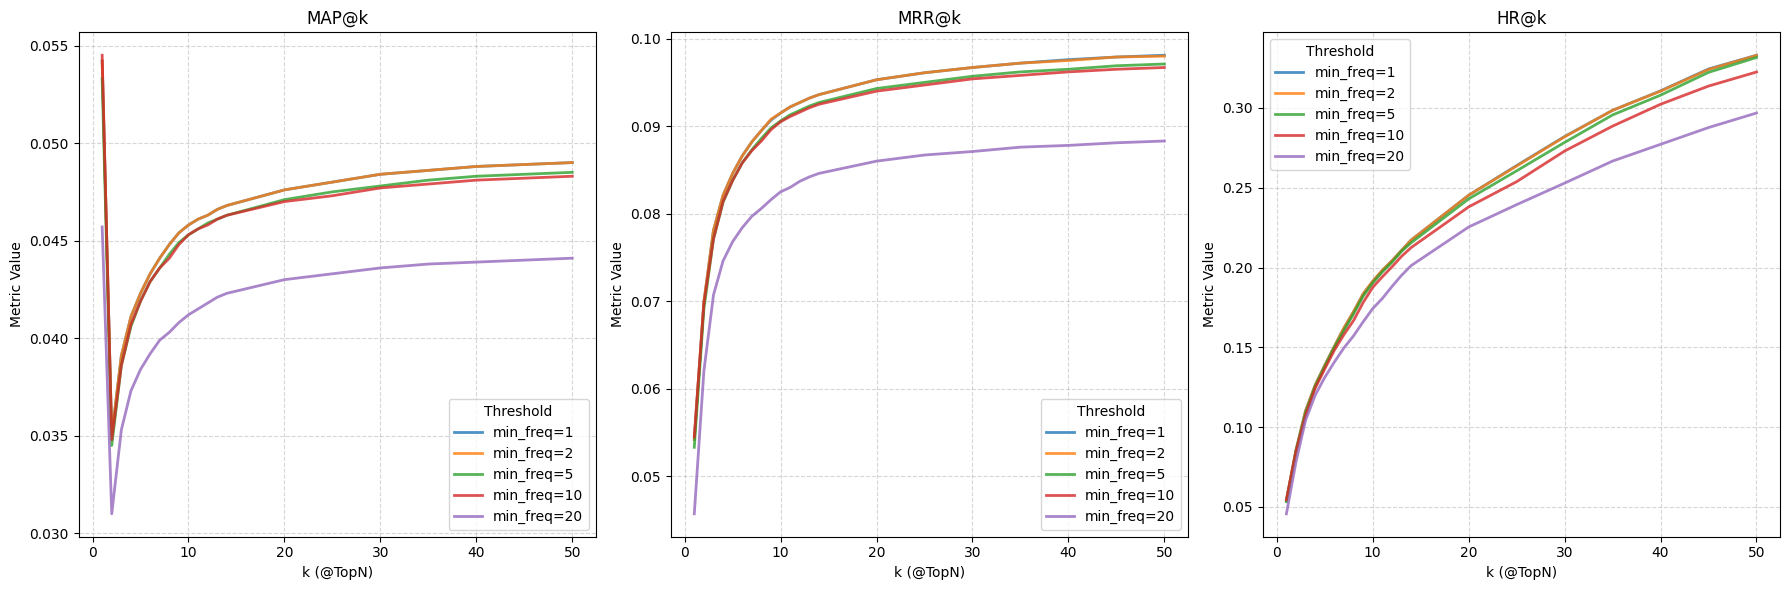

In [426]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_names = ['map', 'mrr', 'hr']
titles = ['MAP@k', 'MRR@k', 'HR@k']

for i, metric in enumerate(metrics_names):
    ax = axes[i]

    for thresh in thresholds:
        ax.plot(k_steps, results[thresh][metric], label=f'min_freq={thresh}', linewidth=2, alpha=0.8)

    ax.set_title(titles[i])
    ax.set_xlabel('k (@TopN)')
    ax.set_ylabel('Metric Value')
    ax.legend(title='Threshold')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

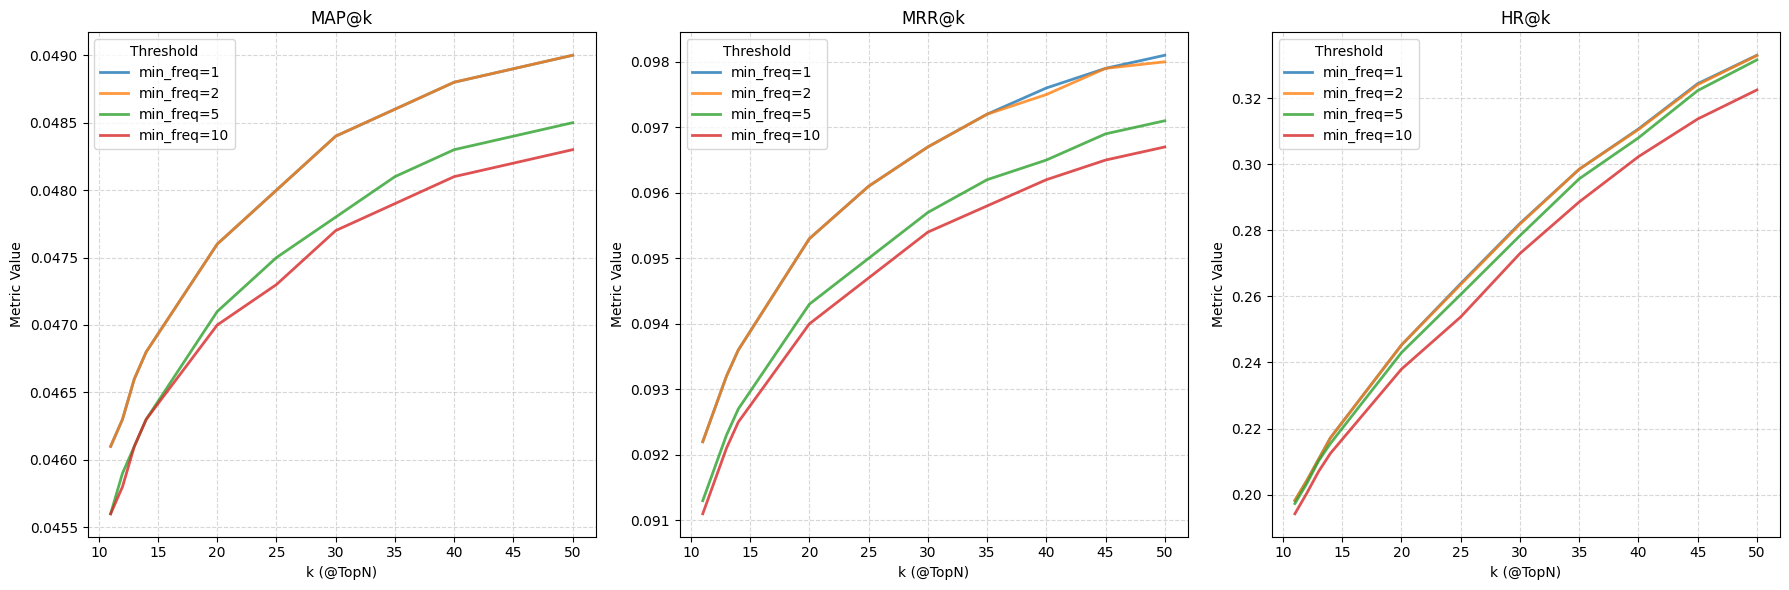

In [432]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, metric in enumerate(metrics_names):
    ax = axes[i]

    for thresh in thresholds[:-1]:
        ax.plot(k_steps[k_steps > 10], np.array(results[thresh][metric])[k_steps > 10], label=f'min_freq={thresh}', linewidth=2, alpha=0.8)

    ax.set_title(titles[i])
    ax.set_xlabel('k (@TopN)')
    ax.set_ylabel('Metric Value')
    ax.legend(title='Threshold')
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Что вы можете сказать на основе полученных графиков? Соответствуют ли они вашим ожиданиям?

**Ответ:**


1.  **Неразличимость порогов 1 и 2:**
    Самый заметный факт на детальных графиках ($k > 10$) — линии для **`min_freq=1` (синяя)** и **`min_freq=2` (оранжевая)** практически **сливаются**.
    *   *Вывод:* Для алгоритма EASE нет существенной разницы, оставлять ли единичные взаимодействия (шум) или удалять их. Модель достаточно устойчива, чтобы извлечь полезный сигнал даже из самых разреженных данных, либо же единичные клики несут столько же полезной информации, сколько и шума.

2.  **Деградация при сильной фильтрации:**
    Начиная с **`min_freq=5` (зеленая)** и далее **`min_freq=10` (красная)**, наблюдается четкое **снижение** всех метрик.
    *   Линии располагаются "лесенкой" вниз: чем строже мы фильтруем данные, тем хуже работает модель.
    *   Самое сильное падение (на общем графике) показывает линия `min_freq=20` (фиолетовая).

**Итог:** EASE работает лучше всего на максимально полных данных. Агрессивная чистка матриц вредит качеству, так как обрезает "длинный хвост" предпочтений, на котором этот алгоритм специализируется. Оптимально использовать порог 2.

**Задание №10. Интерпретируемые рекомендации**

Используйте выученную матрицу весов для item2item рекомендаций. Приведите 10 примеров топ-5 рекомендаций от EASE к сэмплируемым айтемам. Используйте названия фильмов вместо id при выводе рекомендаций. 

In [445]:
train_f = filter_dataframe(train_df, cols=['user_id', 'item_id'], min_freq=2)
train_enc, u2id, i2id = df_encode(train_f)

matrix_curr = sps.coo_matrix(
    (np.ones(train_enc.shape[0]), (train_enc['user_id'], train_enc['item_id'])),
    shape=(len(u2id), len(i2id)),
)

w_best = fit_ease(matrix_curr, reg_weight=10000)

In [446]:
item_titles = items.set_index('item_id')['title'].to_dict()
id2i = {v: k for k, v in i2id.items()}

def get_item_recs(source_item_id, weight_matrix, top_k=5):
    """
    Возвращает топ-K рекомендаций для конкретного айтема на основе весов EASE.
    """

    if source_item_id not in i2id:
        return ["Unknown Item"]

    matrix_idx = i2id[source_item_id]
    item_weights = np.array(weight_matrix[matrix_idx, :]).flatten()

    top_indices = np.argsort(item_weights)[-(top_k+1):][::-1]

    recommendations = []
    for idx in top_indices:
        real_id = id2i[idx]
        if real_id == source_item_id:
            continue

        title = item_titles.get(real_id, f"ID {real_id}")
        score = item_weights[idx]
        recommendations.append(title)

        if len(recommendations) == top_k:
            break

    return recommendations

In [472]:
valid_ids = list(i2id.keys())
sampled_ids = np.random.choice(valid_ids, 10, replace=False)

print(f"{'ИСХОДНЫЙ ФИЛЬМ':<40} | {'РЕКОМЕНДАЦИИ (EASE Weights)':<50}")
print("-" * 100)

for source_id in sampled_ids:
    source_name = item_titles.get(source_id, f"ID {source_id}")
    recs = get_item_recs(source_id, w_best, top_k=5)
    rec_str = " | ".join(recs)
    print(f"{source_name[:38]:<40} | {rec_str}")

ИСХОДНЫЙ ФИЛЬМ                           | РЕКОМЕНДАЦИИ (EASE Weights)                       
----------------------------------------------------------------------------------------------------
Пелена                                   | Дуров | Клиника счастья | Прабабушка легкого поведения | Приманка | Модус
Жизнь впереди                            | Секреты семейной жизни | #Только серьёзные отношения | День города | Гнев человеческий | Маша
Ограбление с ограничениями               | Афера | Секреты семейной жизни | Прабабушка легкого поведения | Крёстная мама | Гнев человеческий
Сердцеедки                               | Клиника счастья | День города | Прабабушка легкого поведения | Маша | Другая женщина
Три дня до весны                         | Девятаев | Коридор бессмертия | Хрустальный | Восемь сотен | Дочь волка
Исход                                    | Гнев человеческий | Поступь хаоса | Радиовспышка | Девятаев | Цвет из иных миров
Помнишь меня?                            | 

Хорошие ли получились рекомендации? Почему? Есть ли хорошие примеры? Есть ли плохие? Почему бывают плохие примеры?

**Ответ:**



>1. Хорошие примеры 


*   **Пример №1 (Франшизы и Вселенные):**
    *   *Исходник:* **Росомаха: Бессмертный**
    *   *Рекомендации:* **Люди Икс: Начало. Росомаха**, **Веном**, **Люди Икс: Апокалипсис**, **Люди Икс: Дни минувшего будущего**.
    *   *Вердикт:* **Идеально.**
    *   *Почему:* Алгоритм четко выделил кластер фанатов Marvel/Comics. Люди, смотревшие один фильм про Росомаху, гарантированно смотрели другие части этой франшизы. Это самая сильная связь, которую может найти коллаборативная фильтрация.

*   **Пример №2 (Узкая тематика):**
    *   *Исходник:* **Три дня до весны** (Военный детектив про блокаду Ленинграда)
    *   *Рекомендации:* **Девятаев**, **Коридор бессмертия**, **Восемь сотен**.
    *   *Вердикт:* **Отлично.**
    *   *Почему:* Все рекомендованные фильмы — это современное военное кино (ВОВ). EASE понял, что аудитория этого фильма интересуется именно военной историей.

*   **Пример №3 (Жанр / Аудитория):**
    *   *Исходник:* **Эпик** (Мультфильм)
    *   *Рекомендации:* **Ральф против Интернета**, **Алита**, **Головоломка**, **Король лев**.
    *   *Вердикт:* **Хорошо.**
    *   *Почему:* Рекомендована качественная анимация и семейное кино. Попадание в целевую аудиторию (дети/семья).

---

> 2. Плохие или странные примеры

Здесь мы видим влияние **популярности** / Popularity Bias

*   **Странность : Вездесущий «Гнев человеческий»**
    *   фильм **«Гнев человеческий»** (фильм Гая Ричи, хит 2021 года) встречается в рекомендациях к: *Жизнь впереди, Ограбление..., Исход, Росомаха, Джуманджи*.
    *   *Почему:* Это эффект **супер-хита**. В момент сбора датасета этот фильм, вероятно, был главной премьерой. Его смотрели *все*. Даже если пользователь зашел посмотреть "Джуманджи", он потом (или до этого) смотрел "Гнев человеческий". 
